# ARTI 502 - Assignment 1
## Training-Testing Neural Network with MNIST Dataset using PyTorch

Name & ID:

Ibrahim Aljurays     2230006656

Mohammed Alshahrani  2230007324

Abdulaziz Alnaim     2230005230

Omar Alsubgh         2210002182

Mohammed Alkaboor    2230004049

Hadi Alhajji         2230000809

### Task 1 - Install and Import PyTorch

In [2]:
# Import PyTorch and computer vision packages
import torch
import torchvision

# Verify installed library versions
print("PyTorch Version: ", torch.__version__)
print("Torchvision Version: ", torchvision.__version__)

PyTorch Version:  2.14.0+cpu
Torchvision Version:  0.29.0+cpu


### Task 2 - Download and Load MNIST Dataset

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Convert PIL images to PyTorch tensors (values scaled to [0, 1])
transform = transforms.ToTensor()

# Download and load training and test splits of the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST(root='./data', train = False, download = True, transform = transform)

# Create mini-batch loaders (shuffle training data to avoid bias)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

# Display dataset details
print("MNIST dataset loaded successfully!")
print("\ntraning samples:",len(train_dataset))
print("test samples:",len(test_dataset))

MNIST dataset loaded successfully!

traning samples: 60000
test samples: 10000


### Task 3 - Inspect the Dataset

In [4]:
# Fetch a single batch of images and their corresponding labels from the training DataLoader
images, labels = next(iter(train_loader))

In [5]:
# Inspect the raw pixel tensor values for the current batch of images
images

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [6]:
# Display the ground-truth target labels for the current batch
labels

tensor([7, 0, 6, 8, 9, 0, 6, 8, 0, 7, 1, 8, 9, 3, 4, 5, 2, 5, 3, 2, 8, 8, 8, 9,
        2, 7, 9, 2, 1, 8, 2, 6])

In [7]:
# Check the tensor dimensions: (batch_size, channels, height, width) and (batch_size,)
print("Images tensor size:",images.size())
print("Labels tensor size:",labels.size())

Images tensor size: torch.Size([32, 1, 28, 28])
Labels tensor size: torch.Size([32])


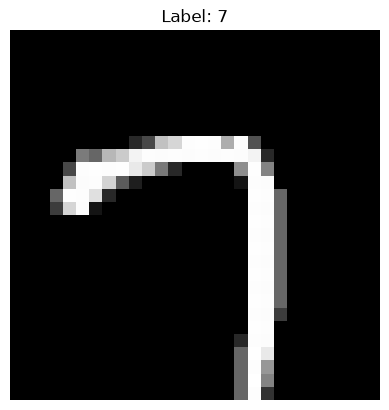

In [8]:
# Visualize the first sample image from the batch
import matplotlib.pyplot as plt

# Remove single-channel dimension (1, 28, 28) -> (28, 28) and render in grayscale
plt.imshow(images[0].squeeze(), cmap="gray")
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

### Task 4 — Create a Simple Network

In [15]:
# Import neural network layers and optimization modules
from torch import nn, optim

# Define a feedforward neural network architecture
class SimpleNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # Reshape input image: (32, 1, 28, 28) → (32, 784)
        self.flatten = nn.Flatten()

        # Fully connected hidden layer mapping 784 inputs to 128 features
        self.hidden = nn.Linear(28 * 28, 128)
        
        # Non-linear activation function
        self.relu = nn.ReLU()
        
        # Output layer producing raw logits for 10 digit classes (0–9)
        self.output = nn.Linear(128, 10)

    # Define the data flow through the network
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Instantiate the model
model = SimpleNetwork()

# Print the network architecture and tensor dimensions before and after flattening
print(model)
print("\nBefore flattening:", images.shape)
print("After flattening:", torch.flatten(images, start_dim=1).shape)

SimpleNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=128, out_features=10, bias=True)
)

Before flattening: torch.Size([32, 1, 28, 28])
After flattening: torch.Size([32, 784])


### Task 5 — Training Function

In [10]:
def train_network(model, train_loader, epochs=5, learning_rate=0.01, momentum=0.9):

    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum
    )

    # Track metrics per epoch
    epoch_losses = []
    epoch_accuracies = []

    for epoch in range(epochs):
        model.train()  # Set training mode

        # Epoch metrics tracking
        total_loss = 0
        correct = 0
        total = 0

        for batch_number, (images, labels) in enumerate(train_loader, start=1):

            optimizer.zero_grad()  # Reset gradients

            # Forward pass and loss calculation
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and weight update
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Calculate batch accuracy
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Log progress every 200 batches
            if batch_number % 200 == 0:
                current_accuracy = 100 * correct / total

                print(
                    f"Epoch {epoch + 1}/{epochs} | "
                    f"Batch {batch_number}/{len(train_loader)} | "
                    f"Loss: {loss.item():.4f} | "
                    f"Accuracy: {current_accuracy:.2f}%"
                )

        # Compute epoch averages
        average_loss = total_loss / len(train_loader)
        accuracy = 100 * correct / total

        epoch_losses.append(average_loss)
        epoch_accuracies.append(accuracy)

        # Print epoch summary
        print(
            f"\nEnd of Epoch {epoch + 1} | "
            f"Average Loss: {average_loss:.4f} | "
            f"Accuracy: {accuracy:.2f}%\n"
        )

    return epoch_losses, epoch_accuracies

### Task 6 — Train the Network and Plot Results

Epoch 1/5 | Batch 200/1875 | Loss: 0.6857 | Accuracy: 75.31%
Epoch 1/5 | Batch 400/1875 | Loss: 0.1796 | Accuracy: 81.98%
Epoch 1/5 | Batch 600/1875 | Loss: 0.7613 | Accuracy: 84.61%
Epoch 1/5 | Batch 800/1875 | Loss: 0.3134 | Accuracy: 86.24%
Epoch 1/5 | Batch 1000/1875 | Loss: 0.1832 | Accuracy: 87.37%
Epoch 1/5 | Batch 1200/1875 | Loss: 0.1120 | Accuracy: 88.19%
Epoch 1/5 | Batch 1400/1875 | Loss: 0.4599 | Accuracy: 88.89%
Epoch 1/5 | Batch 1600/1875 | Loss: 0.1176 | Accuracy: 89.40%
Epoch 1/5 | Batch 1800/1875 | Loss: 0.1333 | Accuracy: 89.87%

End of Epoch 1 | Average Loss: 0.3574 | Accuracy: 90.08%

Epoch 2/5 | Batch 200/1875 | Loss: 0.0565 | Accuracy: 94.64%
Epoch 2/5 | Batch 400/1875 | Loss: 0.2024 | Accuracy: 94.52%
Epoch 2/5 | Batch 600/1875 | Loss: 0.1836 | Accuracy: 94.61%
Epoch 2/5 | Batch 800/1875 | Loss: 0.4235 | Accuracy: 94.78%
Epoch 2/5 | Batch 1000/1875 | Loss: 0.2675 | Accuracy: 94.80%
Epoch 2/5 | Batch 1200/1875 | Loss: 0.1032 | Accuracy: 94.90%
Epoch 2/5 | Batch 1

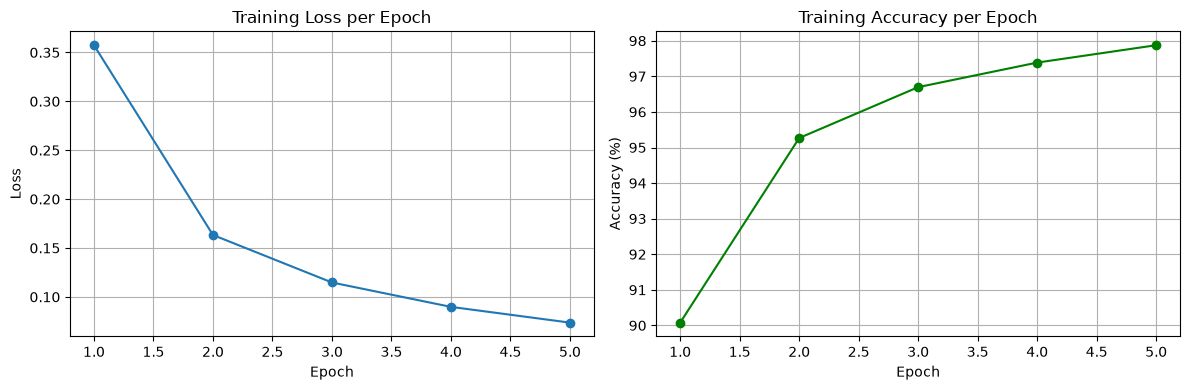

In [11]:
# Create a fresh instance of the neural network
model = SimpleNetwork()

# Run the training loop across 5 epochs using SGD with momentum
epoch_losses, epoch_accuracies = train_network(
    model,
    train_loader,
    epochs=5,
    learning_rate=0.01,
    momentum=0.9
)

# Define x-axis values matching each completed epoch
epochs = range(1, len(epoch_losses) + 1)

# Set up a wide figure to hold two side-by-side metric subplots
plt.figure(figsize=(12, 4))

# Left subplot: Average cross-entropy loss per epoch
plt.subplot(1, 2, 1)
plt.plot(epochs, epoch_losses, marker="o")
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Right subplot: Classification accuracy percentage per epoch
plt.subplot(1, 2, 2)
plt.plot(epochs, epoch_accuracies, marker="o", color="green")
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()

# Automatically adjust spacing between plots and render the figure
plt.tight_layout()
plt.show()

### Task 7 — Test the Network

True labels:      [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]
Predicted labels: [7, 2, 1, 0, 4, 1, 4, 9, 6, 9]


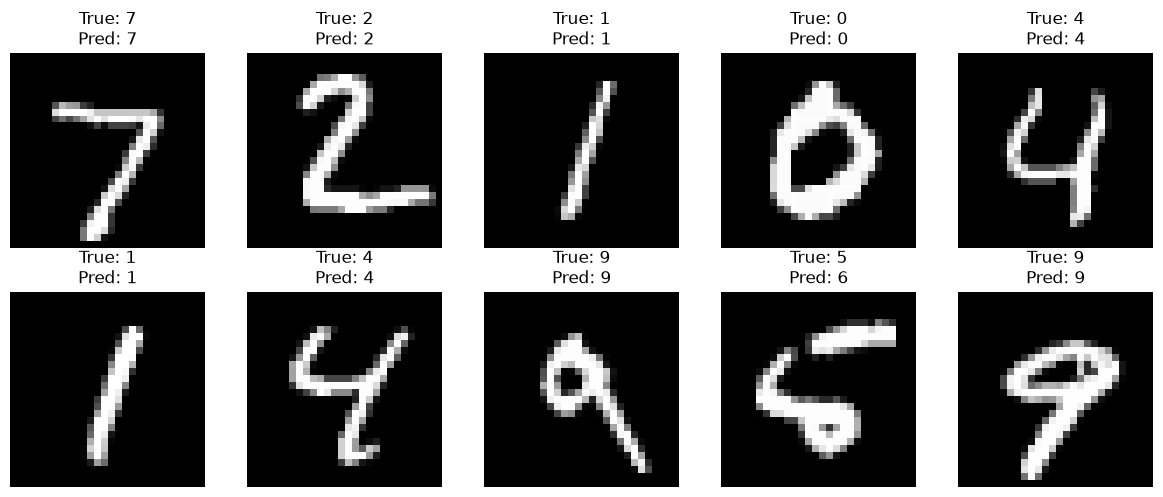

In [14]:
# Set model to evaluation mode (disables dropout/batchnorm training behavior)
model.eval()

# Retrieve a single batch of test samples and labels
test_images, test_labels = next(iter(test_loader))

# Disable gradient calculation for faster inference and lower memory usage
with torch.no_grad():
    test_outputs = model(test_images)              # Forward pass (raw logits)
    predictions = torch.argmax(test_outputs, dim=1)  # Get predicted class indices

# Print side-by-side ground truth vs predictions for the first 10 images
print("True labels:     ", test_labels[:10].tolist())
print("Predicted labels:", predictions[:10].tolist())

# Create a figure grid (2 rows x 5 columns) to display images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Render 28x28 grayscale image
    plt.imshow(test_images[i].squeeze(), cmap="gray")
    
    # Label each image with actual and predicted digit
    plt.title(
        f"True: {test_labels[i].item()}\n"
        f"Pred: {predictions[i].item()}"
    )
    plt.axis("off")  # Remove axis ticks and borders

# Format subplot padding and display the visual results
plt.tight_layout()
plt.show()

### Task 8 — Tuning the Parameters and Model Architecture

In [16]:
# Helper function: evaluate a trained model on the test set
# Returns average test loss and test accuracy , so different configurations can be compared fairly
def evaluate_network(model, test_loader):
    criterion = nn.CrossEntropyLoss()

    model.eval()  # Disable training behavior (not used here, but good practice)

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    average_loss = total_loss / len(test_loader)
    accuracy = 100 * correct / total

    return average_loss, accuracy

#### 8.1 — Tuning Learning Rate and Momentum

In [17]:
# We Try a small grid of learning rate / momentum combinations
# Architecture is kept fixed
lr_momentum_grid = [
    {"learning_rate": 0.001, "momentum": 0.5},
    {"learning_rate": 0.01,  "momentum": 0.5},
    {"learning_rate": 0.01,  "momentum": 0.9},
    {"learning_rate": 0.1,   "momentum": 0.9},
]

lr_momentum_results = []

for config in lr_momentum_grid:
    print(f"\n=== Training with learning_rate={config['learning_rate']}, "
          f"momentum={config['momentum']} ===")

    # Fresh model for every configuration so results are not affected by previous training
    model = SimpleNetwork()

    train_network(
        model,
        train_loader,
        epochs=3,  # fewer epochs to keep the hyperparameter search fast
        learning_rate=config["learning_rate"],
        momentum=config["momentum"]
    )

    test_loss, test_accuracy = evaluate_network(model, test_loader)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

    lr_momentum_results.append({
        "learning_rate": config["learning_rate"],
        "momentum": config["momentum"],
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    })

# Pick the configuration with the highest test accuracy (ties broken by lowest loss)
best_lr_momentum = max(
    lr_momentum_results,
    key=lambda r: (r["test_accuracy"], -r["test_loss"])
)

print("\n--- Learning Rate / Momentum Search Results ---")
for r in lr_momentum_results:
    print(r)

print("\nBest learning rate / momentum configuration:")
print(best_lr_momentum)


=== Training with learning_rate=0.001, momentum=0.5 ===
Epoch 1/3 | Batch 200/1875 | Loss: 2.2510 | Accuracy: 16.75%
Epoch 1/3 | Batch 400/1875 | Loss: 2.1042 | Accuracy: 28.01%
Epoch 1/3 | Batch 600/1875 | Loss: 2.0456 | Accuracy: 37.49%
Epoch 1/3 | Batch 800/1875 | Loss: 2.0276 | Accuracy: 43.77%
Epoch 1/3 | Batch 1000/1875 | Loss: 1.7915 | Accuracy: 48.49%
Epoch 1/3 | Batch 1200/1875 | Loss: 1.6935 | Accuracy: 52.33%
Epoch 1/3 | Batch 1400/1875 | Loss: 1.5488 | Accuracy: 55.17%
Epoch 1/3 | Batch 1600/1875 | Loss: 1.4184 | Accuracy: 57.50%
Epoch 1/3 | Batch 1800/1875 | Loss: 1.2461 | Accuracy: 59.61%

End of Epoch 1 | Average Loss: 1.8215 | Accuracy: 60.32%

Epoch 2/3 | Batch 200/1875 | Loss: 1.1923 | Accuracy: 78.73%
Epoch 2/3 | Batch 400/1875 | Loss: 1.0720 | Accuracy: 79.21%
Epoch 2/3 | Batch 600/1875 | Loss: 1.0037 | Accuracy: 79.60%
Epoch 2/3 | Batch 800/1875 | Loss: 0.8384 | Accuracy: 79.96%
Epoch 2/3 | Batch 1000/1875 | Loss: 0.7654 | Accuracy: 80.35%
Epoch 2/3 | Batch 1200/1

#### 8.2 — Tuning the Model Architecture (Number of Layers and Neurons)

In [19]:
# A configurable network so we can easily change the number of hidden layers
# and the number of neurons per layer
class ConfigurableNetwork(nn.Module):
    def __init__(self, hidden_layer_sizes):
        super().__init__()

        self.flatten = nn.Flatten()

        layers = []
        input_size = 28 * 28  # flattened MNIST image size

        # Build one Linear + ReLU block per requested hidden layer
        for hidden_size in hidden_layer_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        # Final output layer maps the last hidden layer to the 10 digit classes
        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        x = self.network(x)
        return x

In [20]:
# Try a few different architectures, using the best learning rate / momentum from 8.1
architecture_grid = [
    [64],            # 1 hidden layer,  64 neurons
    [128],           # 1 hidden layer, 128 neurons (same as the original SimpleNetwork)
    [256],           # 1 hidden layer, 256 neurons
    [128, 64],       # 2 hidden layers
    [256, 128, 64],  # 3 hidden layers
]

architecture_results = []

for hidden_layer_sizes in architecture_grid:
    print(f"\n=== Training architecture with hidden layers: {hidden_layer_sizes} ===")

    model = ConfigurableNetwork(hidden_layer_sizes)

    train_network(
        model,
        train_loader,
        epochs=3,
        learning_rate=best_lr_momentum["learning_rate"],
        momentum=best_lr_momentum["momentum"]
    )

    test_loss, test_accuracy = evaluate_network(model, test_loader)
    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

    architecture_results.append({
        "hidden_layer_sizes": hidden_layer_sizes,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy
    })

# Pick the architecture with the highest test accuracy (ties broken by lowest loss)
best_architecture = max(
    architecture_results,
    key=lambda r: (r["test_accuracy"], -r["test_loss"])
)

print("\n--- Architecture Search Results ---")
for r in architecture_results:
    print(r)

print("\nBest architecture:")
print(best_architecture)


=== Training architecture with hidden layers: [64] ===
Epoch 1/3 | Batch 200/1875 | Loss: 0.5624 | Accuracy: 73.17%
Epoch 1/3 | Batch 400/1875 | Loss: 0.2878 | Accuracy: 80.86%
Epoch 1/3 | Batch 600/1875 | Loss: 0.0970 | Accuracy: 83.94%
Epoch 1/3 | Batch 800/1875 | Loss: 0.2430 | Accuracy: 85.68%
Epoch 1/3 | Batch 1000/1875 | Loss: 0.3340 | Accuracy: 86.92%
Epoch 1/3 | Batch 1200/1875 | Loss: 0.4251 | Accuracy: 87.70%
Epoch 1/3 | Batch 1400/1875 | Loss: 0.2286 | Accuracy: 88.38%
Epoch 1/3 | Batch 1600/1875 | Loss: 0.1205 | Accuracy: 89.00%
Epoch 1/3 | Batch 1800/1875 | Loss: 0.0857 | Accuracy: 89.51%

End of Epoch 1 | Average Loss: 0.3615 | Accuracy: 89.69%

Epoch 2/3 | Batch 200/1875 | Loss: 0.2429 | Accuracy: 94.39%
Epoch 2/3 | Batch 400/1875 | Loss: 0.1537 | Accuracy: 94.37%
Epoch 2/3 | Batch 600/1875 | Loss: 0.2538 | Accuracy: 94.42%
Epoch 2/3 | Batch 800/1875 | Loss: 0.1127 | Accuracy: 94.53%
Epoch 2/3 | Batch 1000/1875 | Loss: 0.0229 | Accuracy: 94.60%
Epoch 2/3 | Batch 1200/18

#### 8.3 — Best Overall Configuration

In [21]:
# Summary of the best hyperparameters and architecture found above
print("Best learning rate / momentum configuration:")
print(f"  learning_rate = {best_lr_momentum['learning_rate']}")
print(f"  momentum      = {best_lr_momentum['momentum']}")
print(f"  test_loss     = {best_lr_momentum['test_loss']:.4f}")
print(f"  test_accuracy = {best_lr_momentum['test_accuracy']:.2f}%")

print("\nBest architecture:")
print(f"  hidden_layer_sizes = {best_architecture['hidden_layer_sizes']}")
print(f"  test_loss          = {best_architecture['test_loss']:.4f}")
print(f"  test_accuracy      = {best_architecture['test_accuracy']:.2f}%")

# Train one final model combining the best learning rate/momentum AND best architecture found
print("\n=== Training FINAL model with best architecture + best learning rate/momentum ===")
final_model = ConfigurableNetwork(best_architecture["hidden_layer_sizes"])

final_losses, final_accuracies = train_network(
    final_model,
    train_loader,
    epochs=5,
    learning_rate=best_lr_momentum["learning_rate"],
    momentum=best_lr_momentum["momentum"]
)

final_test_loss, final_test_accuracy = evaluate_network(final_model, test_loader)
print(f"\nFinal Test Loss: {final_test_loss:.4f} | Final Test Accuracy: {final_test_accuracy:.2f}%")

Best learning rate / momentum configuration:
  learning_rate = 0.01
  momentum      = 0.9
  test_loss     = 0.1046
  test_accuracy = 96.75%

Best architecture:
  hidden_layer_sizes = [256, 128, 64]
  test_loss          = 0.0856
  test_accuracy      = 97.55%

=== Training FINAL model with best architecture + best learning rate/momentum ===
Epoch 1/5 | Batch 200/1875 | Loss: 0.9147 | Accuracy: 37.56%
Epoch 1/5 | Batch 400/1875 | Loss: 0.3270 | Accuracy: 59.75%
Epoch 1/5 | Batch 600/1875 | Loss: 0.3599 | Accuracy: 69.10%
Epoch 1/5 | Batch 800/1875 | Loss: 0.4726 | Accuracy: 74.32%
Epoch 1/5 | Batch 1000/1875 | Loss: 0.2709 | Accuracy: 77.81%
Epoch 1/5 | Batch 1200/1875 | Loss: 0.1416 | Accuracy: 80.41%
Epoch 1/5 | Batch 1400/1875 | Loss: 0.2225 | Accuracy: 82.37%
Epoch 1/5 | Batch 1600/1875 | Loss: 0.0521 | Accuracy: 83.86%
Epoch 1/5 | Batch 1800/1875 | Loss: 0.2844 | Accuracy: 85.04%

End of Epoch 1 | Average Loss: 0.4619 | Accuracy: 85.44%

Epoch 2/5 | Batch 200/1875 | Loss: 0.0535 | Ac